In [2]:
# Import von Bibliotheken
from datasets import load_dataset
import urllib.request
import io,re
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
# Einlesen weiterer Bibliotheken
import os
# Deutsche Stopwörter laden
!pip install nltk
import nltk
from nltk.tokenize import word_tokenize
nltk.download('punkt')

from nltk.corpus import stopwords
nltk.download('stopwords')
stopwords = stopwords.words('german')

from sklearn.feature_extraction.text import CountVectorizer
from transformers import AutoModelForSequenceClassification, AutoTokenizer, pipeline
!pip install sentence-transformers

[nltk_data] Downloading package punkt to /home/haloh001/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/haloh001/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [3]:
!pip install "transformers==4.47.1" "sentence-transformers"
from sentence_transformers import SentenceTransformer

In [4]:
!pip install bertopic
!pip uninstall -y umap umap-learn
!pip install umap-learn
from umap import UMAP
import hdbscan
import umap
from bertopic import BERTopic
from bertopic.vectorizers import ClassTfidfTransformer

Found existing installation: umap-learn 0.5.12
Uninstalling umap-learn-0.5.12:
  Successfully uninstalled umap-learn-0.5.12
  Using cached umap_learn-0.5.12-py3-none-any.whl.metadata (24 kB)
Using cached umap_learn-0.5.12-py3-none-any.whl (91 kB)


In [5]:
# Einlesen der Langwahlprogramme (aus JSON-Format in ein Wörterbuch)

# für CDU/CSU
with open("cdu-wahlprogramm_2025_absatzweise.json", "r", encoding="utf-8") as datei:
    CDU_text_json = json.load(datei)

# für SPD
with open("spd-wahlprogramm_2025_absatzweise.json", "r", encoding="utf-8") as datei:
    SPD_text_json = json.load(datei)

# für Die Linke
with open("linke-wahlprogramm_2025_absatzweise.json", "r", encoding="utf-8") as datei:
    Linke_text_json = json.load(datei)

# für die AfD
with open("afd-wahlprogramm_2025_absatzweise.json", "r", encoding="utf-8") as datei:
    AfD_text_json = json.load(datei)

# für Bündnis 90/Grüne
with open("gruene-wahlprogramm_2025_absatzweise.json", "r", encoding="utf-8") as datei:
    Grüne_text_json = json.load(datei)

# für FDP
with open("fdp-wahlprogramm_2025_absatzweise.json", "r", encoding="utf-8") as datei:
    FDP_text_json = json.load(datei)

In [6]:
# Überführen aller 'eigentlichen' Texte in eine Liste pro Partei, d.h. ohne Kapitelüberschriften

# Suchfunktion in den "Partei-Wörterbüchern"

def finde_gefilterte_texte(struktur):
    ergebnisse = []
    
    # Fall A: Wenn das aktuelle Element ein Dictionary ist
    if isinstance(struktur, dict):
        # Typ/Art auslesen (liefert None, wenn der Schlüssel fehlt)
        aktueller_typ = struktur.get('type') or struktur.get('art')            # nur Suchen in diesen Elementen
        
        # Prüfen, ob 'text' existiert und der gefundene Typ gültig ist
        if 'text' in struktur and aktueller_typ in ['paragraph', 'bullet', 'absatz']:   # nur Texte überführen mit diesem Typ
            ergebnisse.append(struktur['text'])
        
        # Tiefer in alle Werte schauen für eventuelle Verschachtelungen
        for wert in struktur.values():
            ergebnisse.extend(finde_gefilterte_texte(wert))
                
    # Fall B: Wenn das aktuelle Element eine Liste ist
    elif isinstance(struktur, list):
        for element in struktur:
            ergebnisse.extend(finde_gefilterte_texte(element))
            
    return ergebnisse

CDU_text = finde_gefilterte_texte(CDU_text_json)
#CDU_text = CDU_text[135:]   # da vor der eigentlichen Langfassung im CDU/CSU-Programm noch eine Kurzfassung vorangeht, wird diese ausgeblendet
SPD_text = finde_gefilterte_texte(SPD_text_json)
Linke_text = finde_gefilterte_texte(Linke_text_json)
Grüne_text = finde_gefilterte_texte(Grüne_text_json)
AfD_text = finde_gefilterte_texte(AfD_text_json)
FDP_text = finde_gefilterte_texte(FDP_text_json)

In [7]:
# durchschnittliche Anzahl der Länge jedes einzelnen Dokuments pro Partei VOR BEREINIGUNG
# zur Orientierung die Anzahl der Absätze mit einer Länge von max. 100 Zeichen
durchschnitt_CDU = round(sum(len(s) for s in CDU_text) / len(CDU_text),1)
anzahl_CDU = len([i for i in CDU_text if len(i) < 100])
print("Durchschnittliche Zeichenlänge eines Absatzes im CDU-Programm: ",durchschnitt_CDU)
print("Anzahl aller Absätze: ",len(CDU_text))
print("Anzahl der Absätze mit einer Länge von < 100 Zeichen: ",anzahl_CDU)
print("-----")
durchschnitt_SPD = round(sum(len(s) for s in SPD_text) / len(SPD_text),1)
anzahl_SPD = len([i for i in SPD_text if len(i) < 100])
print("Durchschnittliche Zeichenlänge eines Absatzes im SPD-Programm: ",durchschnitt_SPD)
print("Anzahl aller Absätze: ",len(SPD_text))
print("Anzahl der Absätze mit einer Länge von < 100 Zeichen: ",anzahl_SPD)
print("-----")
durchschnitt_Linke = round(sum(len(s) for s in Linke_text) / len(Linke_text),1)
anzahl_Linke = len([i for i in Linke_text if len(i) < 100])
print("Durchschnittliche Zeichenlänge eines Absatzes im Linke-Programm: ",durchschnitt_Linke)
print("Anzahl aller Absätze: ",len(Linke_text))
print("Anzahl der Absätze mit einer Länge von < 100 Zeichen: ",anzahl_Linke)
print("-----")
durchschnitt_AfD = round(sum(len(s) for s in AfD_text) / len(AfD_text),1)
anzahl_AfD = len([i for i in AfD_text if len(i) < 100])
print("Durchschnittliche Zeichenlänge eines Absatzes im AfD-Programm: ",durchschnitt_AfD)
print("Anzahl aller Absätze: ",len(AfD_text))
print("Anzahl der Absätze mit einer Länge von < 100 Zeichen: ",anzahl_AfD)
print("-----")
durchschnitt_Grüne = round(sum(len(s) for s in Grüne_text) / len(Grüne_text),1)
anzahl_Grüne = len([i for i in Grüne_text if len(i) < 100])
print("Durchschnittliche Zeichenlänge eines Absatzes im Grüne-Programm: ",durchschnitt_Grüne)
print("Anzahl aller Absätze: ",len(Grüne_text))
print("Anzahl der Absätze mit einer Länge von < 100 Zeichen: ",anzahl_Grüne)
print("-----")
durchschnitt_FDP = round(sum(len(s) for s in FDP_text) / len(FDP_text),1)
anzahl_FDP = len([i for i in FDP_text if len(i) < 100])
print("Durchschnittliche Zeichenlänge eines Absatzes im FDP-Programm: ",durchschnitt_FDP)
print("Anzahl aller Absätze: ",len(FDP_text))
print("Anzahl der Absätze mit einer Länge von < 100 Zeichen: ",anzahl_FDP)
print("-----")

Durchschnittliche Zeichenlänge eines Absatzes im CDU-Programm:  257.4
Anzahl aller Absätze:  795
Anzahl der Absätze mit einer Länge von < 100 Zeichen:  153
-----
Durchschnittliche Zeichenlänge eines Absatzes im SPD-Programm:  465.3
Anzahl aller Absätze:  444
Anzahl der Absätze mit einer Länge von < 100 Zeichen:  15
-----
Durchschnittliche Zeichenlänge eines Absatzes im Linke-Programm:  380.0
Anzahl aller Absätze:  665
Anzahl der Absätze mit einer Länge von < 100 Zeichen:  30
-----
Durchschnittliche Zeichenlänge eines Absatzes im AfD-Programm:  299.6
Anzahl aller Absätze:  717
Anzahl der Absätze mit einer Länge von < 100 Zeichen:  108
-----
Durchschnittliche Zeichenlänge eines Absatzes im Grüne-Programm:  649.5
Anzahl aller Absätze:  583
Anzahl der Absätze mit einer Länge von < 100 Zeichen:  7
-----
Durchschnittliche Zeichenlänge eines Absatzes im FDP-Programm:  751.7
Anzahl aller Absätze:  200
Anzahl der Absätze mit einer Länge von < 100 Zeichen:  1
-----


In [8]:
# für das Wahlprogramm der FDP

FDP_text = [text for text in FDP_text if len(text) >= 60]
durchschnitt_FDP_neu = round(sum(len(s) for s in FDP_text) / len(FDP_text),1)
anzahl_FDP_neu = len([i for i in FDP_text if len(i) < 100])
print("Aktualisierte durchschnittliche Länge eines Absatzes im FDP-Programm: ",durchschnitt_FDP_neu, "(alt: ",durchschnitt_FDP, ")")
print("Aktualisierte Anzahl der Absätze mit einer Länge von < 100 Zeichen: ",anzahl_FDP_neu, "(alt: ",anzahl_FDP, ")")

Aktualisierte durchschnittliche Länge eines Absatzes im FDP-Programm:  755.3 (alt:  751.7 )
Aktualisierte Anzahl der Absätze mit einer Länge von < 100 Zeichen:  0 (alt:  1 )


In [9]:
# Herauslöschen der unerwünschten Texte
# wir gehen nicht nach Länge, da teils längere Text inhaltslos sind und kürzere nicht
# manuelles Löschen bevorzugt statt pauschales Löschen z.B. "alles < 60 Zeichen"

# einzelne Löschen von Indizes verschiebt diese, daher der Weg über eine Liste
loesch_indizes = {1, 8, 11, 13, 22, 33, 34, 35, 52}

# Neue Liste erstellen ohne die unerwünschten Indizes
SPD_text = [element for index, element in enumerate(SPD_text) if index not in loesch_indizes]

durchschnitt_SPD_neu = round(sum(len(s) for s in SPD_text) / len(SPD_text),1)
anzahl_SPD_neu = len([i for i in SPD_text if len(i) < 100])
print("Aktualisierte durchschnittliche Länge eines Absatzes im SPD-Programm: ",durchschnitt_SPD_neu, "(alt: ",durchschnitt_SPD, ")")
print("Aktualisierte Anzahl der Absätze mit einer Länge von < 100 Zeichen: ",anzahl_SPD_neu, "(alt: ",anzahl_SPD, ")")

Aktualisierte durchschnittliche Länge eines Absatzes im SPD-Programm:  473.6 (alt:  465.3 )
Aktualisierte Anzahl der Absätze mit einer Länge von < 100 Zeichen:  6 (alt:  15 )


In [10]:
# Herauslöschen der unerwünschten Texte, analog des Ansatzes bei der SPD
loesch_indizes = {13, 75, 93, 101, 104, 106, 115}
Linke_text = [element for index, element in enumerate(Linke_text) if index not in loesch_indizes]

durchschnitt_Linke_neu = round(sum(len(s) for s in Linke_text) / len(Linke_text),1)
anzahl_Linke_neu = len([i for i in Linke_text if len(i) < 100])
print("Aktualisierte durchschnittliche Länge eines Absatzes im Linke-Programm: ",durchschnitt_Linke_neu, "(alt: ",durchschnitt_Linke, ")")
print("Aktualisierte Anzahl der Absätze mit einer Länge von < 100 Zeichen: ",anzahl_Linke_neu, "(alt: ",anzahl_Linke, ")")

Aktualisierte durchschnittliche Länge eines Absatzes im Linke-Programm:  383.5 (alt:  380.0 )
Aktualisierte Anzahl der Absätze mit einer Länge von < 100 Zeichen:  23 (alt:  30 )


In [11]:
# Herauslöschen der unerwünschten Texte, analog des Ansatzes bei der SPD
loesch_indizes = {8, 10, 13, 16, 23, 24}
Grüne_text = [element for index, element in enumerate(Grüne_text) if index not in loesch_indizes]

durchschnitt_Grüne_neu = round(sum(len(s) for s in Grüne_text) / len(Grüne_text),1)
anzahl_Grüne_neu = len([i for i in Grüne_text if len(i) < 100])
print("Aktualisierte durchschnittliche Länge eines Absatzes im Grüne-Programm: ",durchschnitt_Grüne_neu, "(alt: ",durchschnitt_Grüne, ")")
print("Aktualisierte Anzahl der Absätze mit einer Länge von < 100 Zeichen: ",anzahl_Grüne_neu, "(alt: ",anzahl_Grüne, ")")

Aktualisierte durchschnittliche Länge eines Absatzes im Grüne-Programm:  655.2 (alt:  649.5 )
Aktualisierte Anzahl der Absätze mit einer Länge von < 100 Zeichen:  4 (alt:  7 )


In [12]:
# Herauslöschen der unerwünschten Texte, analog des Ansatzes bei der SPD
loesch_indizes = {0,}
AfD_text = [element for index, element in enumerate(AfD_text) if index not in loesch_indizes]

durchschnitt_AfD_neu = round(sum(len(s) for s in AfD_text) / len(AfD_text),1)
anzahl_AfD_neu = len([i for i in AfD_text if len(i) < 100])
print("Aktualisierte durchschnittliche Länge eines Absatzes im AfD-Programm: ",durchschnitt_AfD_neu, "(alt: ",durchschnitt_AfD, ")")
print("Aktualisierte Anzahl der Absätze mit einer Länge von < 100 Zeichen: ",anzahl_AfD_neu, "(alt: ",anzahl_AfD, ")")

Aktualisierte durchschnittliche Länge eines Absatzes im AfD-Programm:  299.8 (alt:  299.6 )
Aktualisierte Anzahl der Absätze mit einer Länge von < 100 Zeichen:  108 (alt:  108 )


In [13]:
# Anderer Ansatz: Herauslöschen der Strings unter 90 Zeichen
# diese fassen im Vorfeld die Punkte zusammen, die anschließend ausführlich in längeren Fließtexten samt bullet points folgen

CDU_text = [text for text in CDU_text if len(text) >= 89]

durchschnitt_CDU_neu = round(sum(len(s) for s in CDU_text) / len(CDU_text),1)
anzahl_CDU_neu = len([i for i in CDU_text if len(i) < 100])
print("Aktualisierte durchschnittliche Länge eines Absatzes im CDU-Programm: ",durchschnitt_CDU_neu, "(alt: ",durchschnitt_CDU, ")")
print("Aktualisierte Anzahl der Absätze mit einer Länge von < 100 Zeichen: ",anzahl_CDU_neu, "(alt: ",anzahl_CDU, ")")

Aktualisierte durchschnittliche Länge eines Absatzes im CDU-Programm:  308.6 (alt:  257.4 )
Aktualisierte Anzahl der Absätze mit einer Länge von < 100 Zeichen:  4 (alt:  153 )


In [14]:
# aktualisierte durchschnittliche Länge jedes einzelnen Dokuments pro Partei NACH BEREINIGUNG
print("Durchschnittliche Länge eines Absatzes im CDU-Programm: ",durchschnitt_CDU_neu)
print("Anzahl der Gesamtabsätze: ",len(CDU_text))
print("Anzahl der Absätze mit einer Länge von < 100 Zeichen: ",anzahl_CDU_neu)
print("Verhältnis 'Absätze < 100 Zeichen' zu 'Gesamtabsätze' in %: ",round(anzahl_CDU_neu/len(CDU_text)*100,2))
print("-----")
print("Durchschnittliche Länge eines Absatzes im SPD-Programm: ",durchschnitt_SPD_neu)
print("Anzahl der Gesamtabsätze: ",len(SPD_text))
print("Anzahl der Absätze mit einer Länge von < 100 Zeichen: ",anzahl_SPD_neu)
print("Verhältnis 'Absätze < 100 Zeichen' zu 'Gesamtabsätze' in %: ",round(anzahl_SPD_neu/len(SPD_text)*100,2))
print("-----")
print("Durchschnittliche Länge eines Absatzes im Linke-Programm: ",durchschnitt_Linke_neu)
print("Anzahl der Gesamtabsätze: ",len(Linke_text))
print("Anzahl der Absätze mit einer Länge von < 100 Zeichen: ",anzahl_Linke_neu)
print("Verhältnis 'Absätze < 100 Zeichen' zu 'Gesamtabsätze' in %: ",round(anzahl_Linke_neu/len(Linke_text)*100,2))
print("-----")
print("Durchschnittliche Länge eines Absatzes im AfD-Programm: ",durchschnitt_AfD_neu)
print("Anzahl der Gesamtabsätze: ",len(AfD_text))
print("Anzahl der Absätze mit einer Länge von < 100 Zeichen: ",anzahl_AfD_neu)
print("Verhältnis 'Absätze < 100 Zeichen' zu 'Gesamtabsätze' in %: ",round(anzahl_AfD_neu/len(AfD_text)*100,2))
print("-----")
print("Durchschnittliche Länge eines Absatzes im Grüne-Programm: ",durchschnitt_Grüne_neu)
print("Anzahl der Gesamtabsätze: ",len(Grüne_text))
print("Anzahl der Absätze mit einer Länge von < 100 Zeichen: ",anzahl_Grüne_neu)
print("Verhältnis 'Absätze < 100 Zeichen' zu 'Gesamtabsätze' in %: ",round(anzahl_Grüne_neu/len(Grüne_text)*100,2))
print("-----")
print("Durchschnittliche Länge eines Absatzes im FDP-Programm: ",durchschnitt_FDP_neu)
print("Anzahl der Gesamtabsätze: ",len(FDP_text))
print("Anzahl der Absätze mit einer Länge von < 100 Zeichen: ",anzahl_FDP_neu)
print("Verhältnis 'Absätze < 100 Zeichen' zu 'Gesamtabsätze' in %: ",round(anzahl_FDP_neu/len(FDP_text)*100,2))
print("-----")

Durchschnittliche Länge eines Absatzes im CDU-Programm:  308.6
Anzahl der Gesamtabsätze:  646
Anzahl der Absätze mit einer Länge von < 100 Zeichen:  4
Verhältnis 'Absätze < 100 Zeichen' zu 'Gesamtabsätze' in %:  0.62
-----
Durchschnittliche Länge eines Absatzes im SPD-Programm:  473.6
Anzahl der Gesamtabsätze:  435
Anzahl der Absätze mit einer Länge von < 100 Zeichen:  6
Verhältnis 'Absätze < 100 Zeichen' zu 'Gesamtabsätze' in %:  1.38
-----
Durchschnittliche Länge eines Absatzes im Linke-Programm:  383.5
Anzahl der Gesamtabsätze:  658
Anzahl der Absätze mit einer Länge von < 100 Zeichen:  23
Verhältnis 'Absätze < 100 Zeichen' zu 'Gesamtabsätze' in %:  3.5
-----
Durchschnittliche Länge eines Absatzes im AfD-Programm:  299.8
Anzahl der Gesamtabsätze:  716
Anzahl der Absätze mit einer Länge von < 100 Zeichen:  108
Verhältnis 'Absätze < 100 Zeichen' zu 'Gesamtabsätze' in %:  15.08
-----
Durchschnittliche Länge eines Absatzes im Grüne-Programm:  655.2
Anzahl der Gesamtabsätze:  577
Anzahl 

In [15]:
# SCHRITT 2: ZUSAMMENFASSEN DER BULLET POINTS UND ANHÄNGEN DIESER 'GESAMMELTEN BULLET POINTS'
#            an an den vorherigen (normalen Fließtext-)Absatz (für Ziel 2)

# zunächst die Ermittlung wie viele Absätze 'bullet points' sind, d.h. mit Sonderzeichen wie Bindestrich oder '•' beginnen

print(f"Gefundene Strings im CDU/CSU-Wahlprogramm: {len(s := [t for t in CDU_text if t and not t[0].isalpha()])} von {len(CDU_text)} ({(len(s)/len(CDU_text)*100 if CDU_text else 0):.2f}%)")
print(f"Gefundene Strings im SPD-Wahlprogramm: {len(s := [t for t in SPD_text if t and not t[0].isalpha()])} von {len(SPD_text)} ({(len(s)/len(SPD_text)*100 if SPD_text else 0):.2f}%)")
print(f"Gefundene Strings im Linke-Wahlprogramm: {len(s := [t for t in Linke_text if t and not t[0].isalpha()])} von {len(Linke_text)} ({(len(s)/len(Linke_text)*100 if Linke_text else 0):.2f}%)")
print(f"Gefundene Strings im Grüne-Wahlprogramm: {len(s := [t for t in Grüne_text if t and not t[0].isalpha()])} von {len(Grüne_text)} ({(len(s)/len(Grüne_text)*100 if Grüne_text else 0):.2f}%)")
print(f"Gefundene Strings im AfD-Wahlprogramm: {len(s := [t for t in AfD_text if t and not t[0].isalpha()])} von {len(AfD_text)} ({(len(s)/len(AfD_text)*100 if AfD_text else 0):.2f}%)")
print(f"Gefundene Strings im FDP-Wahlprogramm: {len(s := [t for t in FDP_text if t and not t[0].isalpha()])} von {len(FDP_text)} ({(len(s)/len(FDP_text)*100 if FDP_text else 0):.2f}%)")


Gefundene Strings im CDU/CSU-Wahlprogramm: 545 von 646 (84.37%)
Gefundene Strings im SPD-Wahlprogramm: 16 von 435 (3.68%)
Gefundene Strings im Linke-Wahlprogramm: 481 von 658 (73.10%)
Gefundene Strings im Grüne-Wahlprogramm: 0 von 577 (0.00%)
Gefundene Strings im AfD-Wahlprogramm: 216 von 716 (30.17%)
Gefundene Strings im FDP-Wahlprogramm: 0 von 199 (0.00%)


In [16]:
# in anderem Notebook ermittelte Durchschnittswerte
cdu_avg_length = 281
spd_avg_length = 465
linke_avg_length = 380
grüne_avg_length = 650
afd_avg_length = 300
fdp_avg_length = 752

In [17]:
# Ermittlung der Kehrtwerte, die als Gewichtungsfaktoren für die spätere Kategorie-Zuteilung herangezogen werden

# für 'CDU_text'
# Der vorgegebene Mittelwert

# Neue Liste für die Ergebnisse
ergebnis_nach_zeichen = []

# 2. Liste iterieren und Verhältnis berechnen
for chunk in CDU_text:
    laenge_zeichen = len(chunk)
    
    # Berechnet: cdu_avg_length / zeichenlänge (verhindert Fehler bei leeren Texten)
    verhaeltnis = float(round(cdu_avg_length / laenge_zeichen,2))
    
    ergebnis_nach_zeichen.append(verhaeltnis)

# 3. Ausgabe der neuen Liste
kehrwert_cdu = []
for i in ergebnis_nach_zeichen:
    x = round(float(1/i),2)
    kehrwert_cdu.append(x)

In [18]:
# für 'SPD_text'
# Der vorgegebene Mittelwert

# Neue Liste für die Ergebnisse
ergebnis_nach_zeichen = []

# 2. Liste iterieren und Verhältnis berechnen
for chunk in SPD_text:
    laenge_zeichen = len(chunk)
    
    # Berechnet: cdu_avg_length / zeichenlänge (verhindert Fehler bei leeren Texten)
    verhaeltnis = float(round(spd_avg_length / laenge_zeichen,2))
    
    ergebnis_nach_zeichen.append(verhaeltnis)

# 3. Ausgabe der neuen Liste
kehrwert_spd = []
for i in ergebnis_nach_zeichen:
    x = round(float(1/i),2)
    kehrwert_spd.append(x)

In [19]:
# für 'Linke_text'
# Der vorgegebene Mittelwert

# Neue Liste für die Ergebnisse
ergebnis_nach_zeichen = []

# 2. Liste iterieren und Verhältnis berechnen
for chunk in Linke_text:
    laenge_zeichen = len(chunk)
    
    # Berechnet: cdu_avg_length / zeichenlänge (verhindert Fehler bei leeren Texten)
    verhaeltnis = float(round(linke_avg_length / laenge_zeichen,2))
    
    ergebnis_nach_zeichen.append(verhaeltnis)

# 3. Ausgabe der neuen Liste
kehrwert_linke = []
for i in ergebnis_nach_zeichen:
    x = round(float(1/i),2)
    kehrwert_linke.append(x)

In [20]:
# für 'Grüne_text'
# Der vorgegebene Mittelwert

# Neue Liste für die Ergebnisse
ergebnis_nach_zeichen = []

# 2. Liste iterieren und Verhältnis berechnen
for chunk in Grüne_text:
    laenge_zeichen = len(chunk)
    
    # Berechnet: cdu_avg_length / zeichenlänge (verhindert Fehler bei leeren Texten)
    verhaeltnis = float(round(grüne_avg_length / laenge_zeichen,2))
    
    ergebnis_nach_zeichen.append(verhaeltnis)

# 3. Ausgabe der neuen Liste
kehrwert_grüne = []
for i in ergebnis_nach_zeichen:
    x = round(float(1/i),2)
    kehrwert_grüne.append(x)

In [21]:
# für 'AfD_text'
# Der vorgegebene Mittelwert

# Neue Liste für die Ergebnisse
ergebnis_nach_zeichen = []

# 2. Liste iterieren und Verhältnis berechnen
for chunk in AfD_text:
    laenge_zeichen = len(chunk)
    
    # Berechnet: cdu_avg_length / zeichenlänge (verhindert Fehler bei leeren Texten)
    verhaeltnis = float(round(afd_avg_length / laenge_zeichen,2))
    
    ergebnis_nach_zeichen.append(verhaeltnis)

# 3. Ausgabe der neuen Liste
kehrwert_afd = []
for i in ergebnis_nach_zeichen:
    x = round(float(1/i),2)
    kehrwert_afd.append(x)

In [22]:
# für 'FDP_text'
# Der vorgegebene Mittelwert

# Neue Liste für die Ergebnisse
ergebnis_nach_zeichen = []

# 2. Liste iterieren und Verhältnis berechnen
for chunk in FDP_text:
    laenge_zeichen = len(chunk)
    
    # Berechnet: cdu_avg_length / zeichenlänge (verhindert Fehler bei leeren Texten)
    verhaeltnis = float(round(fdp_avg_length / laenge_zeichen,2))
    
    ergebnis_nach_zeichen.append(verhaeltnis)

# 3. Ausgabe der neuen Liste
kehrwert_fdp = []
for i in ergebnis_nach_zeichen:
    x = round(float(1/i),2)
    kehrwert_fdp.append(x)

In [23]:
# Liste wieder laden mit den eingelesenen und 'vorbereiteten' (um Phrasen, Einleitungen, Begrüßung usw. bereinigt...)

with open("text_liste_CDU_1_json.json", "r", encoding="utf-8") as f:
    text_liste_CDU_1_clean = json.load(f)

with open("text_liste_CDU_2_json.json", "r", encoding="utf-8") as f:
    text_liste_CDU_2_clean = json.load(f)

with open("text_liste_CDU_3_json.json", "r", encoding="utf-8") as f:
    text_liste_CDU_3_clean = json.load(f)

with open("text_liste_CDU_4_json.json", "r", encoding="utf-8") as f:
    text_liste_CDU_4_clean = json.load(f)

with open("text_liste_CDU_5_json.json", "r", encoding="utf-8") as f:
    text_liste_CDU_5_clean = json.load(f)

with open("text_liste_SPD_1_json.json", "r", encoding="utf-8") as f:
    text_liste_SPD_1_clean = json.load(f)

with open("text_liste_SPD_2_json.json", "r", encoding="utf-8") as f:
    text_liste_SPD_2_clean = json.load(f)

with open("text_liste_SPD_3_json.json", "r", encoding="utf-8") as f:
    text_liste_SPD_3_clean = json.load(f)

with open("text_liste_SPD_4_json.json", "r", encoding="utf-8") as f:
    text_liste_SPD_4_clean = json.load(f)

with open("text_liste_SPD_5_json.json", "r", encoding="utf-8") as f:
    text_liste_SPD_5_clean = json.load(f)

with open("text_liste_Linke_1_json.json", "r", encoding="utf-8") as f:
    text_liste_Linke_1_clean = json.load(f)

with open("text_liste_Linke_2_json.json", "r", encoding="utf-8") as f:
    text_liste_Linke_2_clean = json.load(f)

with open("text_liste_Linke_3_json.json", "r", encoding="utf-8") as f:
    text_liste_Linke_3_clean = json.load(f)

with open("text_liste_Linke_4_json.json", "r", encoding="utf-8") as f:
    text_liste_Linke_4_clean = json.load(f)

with open("text_liste_Linke_5_json.json", "r", encoding="utf-8") as f:
    text_liste_Linke_5_clean = json.load(f)

with open("text_liste_Grüne_1_json.json", "r", encoding="utf-8") as f:
    text_liste_Grüne_1_clean = json.load(f)

with open("text_liste_Grüne_2_json.json", "r", encoding="utf-8") as f:
    text_liste_Grüne_2_clean = json.load(f)

with open("text_liste_Grüne_3_json.json", "r", encoding="utf-8") as f:
    text_liste_Grüne_3_clean = json.load(f)

with open("text_liste_Grüne_4_json.json", "r", encoding="utf-8") as f:
    text_liste_Grüne_4_clean = json.load(f)

with open("text_liste_Grüne_5_json.json", "r", encoding="utf-8") as f:
    text_liste_Grüne_5_clean = json.load(f)

with open("text_liste_AfD_1_json.json", "r", encoding="utf-8") as f:
    text_liste_AfD_1_clean = json.load(f)

with open("text_liste_AfD_2_json.json", "r", encoding="utf-8") as f:
    text_liste_AfD_2_clean = json.load(f)

with open("text_liste_AfD_3_json.json", "r", encoding="utf-8") as f:
    text_liste_AfD_3_clean = json.load(f)

with open("text_liste_AfD_4_json.json", "r", encoding="utf-8") as f:
    text_liste_AfD_4_clean = json.load(f)

with open("text_liste_AfD_5_json.json", "r", encoding="utf-8") as f:
    text_liste_AfD_5_clean = json.load(f)

with open("text_liste_FDP_1_json.json", "r", encoding="utf-8") as f:
    text_liste_FDP_1_clean = json.load(f)

with open("text_liste_FDP_2_json.json", "r", encoding="utf-8") as f:
    text_liste_FDP_2_clean = json.load(f)

with open("text_liste_FDP_3_json.json", "r", encoding="utf-8") as f:
    text_liste_FDP_3_clean = json.load(f)

with open("text_liste_FDP_4_json.json", "r", encoding="utf-8") as f:
    text_liste_FDP_4_clean = json.load(f)

with open("text_liste_FDP_5_json.json", "r", encoding="utf-8") as f:
    text_liste_FDP_5_clean = json.load(f)

In [24]:
print(len(text_liste_CDU_4_clean))
print(len(text_liste_CDU_4_clean[0]))
print(text_liste_CDU_4_clean[0][:1000])

88
16464
Was war das denn? 25 Minuten abgelesene Empörung über den Oppositionsführer. Herzlichen Glückwunsch, Sie verwechseln den Plenarsaal des Deutschen Bundestages offensichtlich mit einem Juso-Bundeskongress. Wollen Sie uns allen Ernstes diese halbe Stunde hier heute Morgen zumuten als eine Abschlussbilanz Ihrer dreijährigen Amtszeit als Bundeskanzler der Bundesrepublik Deutschland? Ist das allen Ernstes das, was Sie sozusagen zum Abschluss dieser drei Jahre hier vortragen und anschließend den Bürgerinnen und Bürgern in Deutschland zur Fortsetzung anbieten? Wissen Sie, wie Sie mir vorkommen, Sie beide, Herr Habeck und Herr Scholz? Wie zwei angestellte Geschäftsführer, die das Unternehmen vor die Wand gefahren haben, anschließend zu den Eigentümern gehen und sagen: Wir würden das jetzt gerne noch mal vier Jahre so weitermachen. So kommen Sie mir vor. Wissen Sie, was im normalen Leben bei Ihnen ist das Jahrzehnte her, dass Sie es kennengelernt haben die Eigentümer sagen würden, wenn 

In [25]:
!pip install langchain_text_splitters
from langchain_text_splitters import RecursiveCharacterTextSplitter

def split_text(text):
    # chunk_size: Maximale Zeichenanzahl pro Abschnitt
    # chunk_overlap: Wie viele Zeichen vom vorherigen Abschnitt wiederholt werden
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=800,       # -> entspricht ca. 100 Wörtern
        chunk_overlap=100,       # keine chun_overlap
        separators = ["\n\n", "\n", ". ", "? ", "! ", " ", ""] # Sucht erst nach Absätzen, dann Sätzen, dann Wörtern
    )

    # Gibt eine Liste von Strings zurück
    return splitter.split_text(text)

In [26]:
# Wahlprogramme nicht in chunks aufteilen; Annahme: Absätze behandeln i.d.R. ein Thema
CDU_WP_chunks = CDU_text
SPD_WP_chunks = SPD_text
Grüne_WP_chunks = Grüne_text
AfD_WP_chunks = AfD_text
Linke_WP_chunks = Linke_text
FDP_WP_chunks = FDP_text

# in integer verwandeln, wichtig für später zur Berechnung der Themenanteile

CDU_WP_chunks_len = len(CDU_WP_chunks)
SPD_WP_chunks_len = len(SPD_WP_chunks)
Grüne_WP_chunks_len = len(Grüne_WP_chunks)
AfD_WP_chunks_len = len(AfD_WP_chunks)
Linke_WP_chunks_len = len(Linke_WP_chunks)
FDP_WP_chunks_len = len(FDP_WP_chunks)

CDU_anteil = kehrwert_cdu
SPD_anteil = kehrwert_spd
Linke_anteil = kehrwert_linke
Grüne_anteil = kehrwert_grüne
AfD_anteil = kehrwert_afd
FDP_anteil = kehrwert_fdp

In [27]:
# Bundestagsreden in chunks aufteilen von 800 Zeichen, ohne chunk_overlap

CDU_1_chunks = [chunk for rede in text_liste_CDU_1_clean for chunk in split_text(rede)]
CDU_2_chunks = [chunk for rede in text_liste_CDU_2_clean for chunk in split_text(rede)]
CDU_3_chunks = [chunk for rede in text_liste_CDU_3_clean for chunk in split_text(rede)]
CDU_4_chunks = [chunk for rede in text_liste_CDU_4_clean for chunk in split_text(rede)]
CDU_5_chunks = [chunk for rede in text_liste_CDU_5_clean for chunk in split_text(rede)]

SPD_1_chunks = [chunk for rede in text_liste_SPD_1_clean for chunk in split_text(rede)]
SPD_2_chunks = [chunk for rede in text_liste_SPD_2_clean for chunk in split_text(rede)]
SPD_3_chunks = [chunk for rede in text_liste_SPD_3_clean for chunk in split_text(rede)]
SPD_4_chunks = [chunk for rede in text_liste_SPD_4_clean for chunk in split_text(rede)]
SPD_5_chunks = [chunk for rede in text_liste_SPD_5_clean for chunk in split_text(rede)]

Linke_1_chunks = [chunk for rede in text_liste_Linke_1_clean for chunk in split_text(rede)]
Linke_2_chunks = [chunk for rede in text_liste_Linke_2_clean for chunk in split_text(rede)]
Linke_3_chunks = [chunk for rede in text_liste_Linke_3_clean for chunk in split_text(rede)]
Linke_4_chunks = [chunk for rede in text_liste_Linke_4_clean for chunk in split_text(rede)]
Linke_5_chunks = [chunk for rede in text_liste_Linke_5_clean for chunk in split_text(rede)]

Grüne_1_chunks = [chunk for rede in text_liste_Grüne_1_clean for chunk in split_text(rede)]
Grüne_2_chunks = [chunk for rede in text_liste_Grüne_2_clean for chunk in split_text(rede)]
Grüne_3_chunks = [chunk for rede in text_liste_Grüne_3_clean for chunk in split_text(rede)]
Grüne_4_chunks = [chunk for rede in text_liste_Grüne_4_clean for chunk in split_text(rede)]
Grüne_5_chunks = [chunk for rede in text_liste_Grüne_5_clean for chunk in split_text(rede)]
# Grüne_5_chunks = split_text(text_liste_Grüne_5_str)

AfD_1_chunks = [chunk for rede in text_liste_AfD_1_clean for chunk in split_text(rede)]
AfD_2_chunks = [chunk for rede in text_liste_AfD_2_clean for chunk in split_text(rede)]
AfD_3_chunks = [chunk for rede in text_liste_AfD_3_clean for chunk in split_text(rede)]
AfD_4_chunks = [chunk for rede in text_liste_AfD_4_clean for chunk in split_text(rede)]
AfD_5_chunks = [chunk for rede in text_liste_AfD_5_clean for chunk in split_text(rede)]

FDP_1_chunks = [chunk for rede in text_liste_FDP_1_clean for chunk in split_text(rede)]
FDP_2_chunks = [chunk for rede in text_liste_FDP_2_clean for chunk in split_text(rede)]
FDP_3_chunks = [chunk for rede in text_liste_FDP_3_clean for chunk in split_text(rede)]
FDP_4_chunks = [chunk for rede in text_liste_FDP_4_clean for chunk in split_text(rede)]

# in integer verwandeln, wichtig für später zur Berechnung der Themenanteile

CDU_1_chunks_len = len(CDU_1_chunks)
CDU_2_chunks_len = len(CDU_2_chunks)
CDU_3_chunks_len = len(CDU_3_chunks)
CDU_4_chunks_len = len(CDU_4_chunks)
CDU_5_chunks_len = len(CDU_5_chunks)

SPD_1_chunks_len = len(SPD_1_chunks)
SPD_2_chunks_len = len(SPD_2_chunks)
SPD_3_chunks_len = len(SPD_3_chunks)
SPD_4_chunks_len = len(SPD_4_chunks)
SPD_5_chunks_len = len(SPD_5_chunks)

Grüne_1_chunks_len = len(Grüne_1_chunks)
Grüne_2_chunks_len = len(Grüne_2_chunks)
Grüne_3_chunks_len = len(Grüne_3_chunks)
Grüne_4_chunks_len = len(Grüne_4_chunks)
Grüne_5_chunks_len = len(Grüne_5_chunks)

Linke_1_chunks_len = len(Linke_1_chunks)
Linke_2_chunks_len = len(Linke_2_chunks)
Linke_3_chunks_len = len(Linke_3_chunks)
Linke_4_chunks_len = len(Linke_4_chunks)
Linke_5_chunks_len = len(Linke_5_chunks)

AfD_1_chunks_len = len(AfD_1_chunks)
AfD_2_chunks_len = len(AfD_2_chunks)
AfD_3_chunks_len = len(AfD_3_chunks)
AfD_4_chunks_len = len(AfD_4_chunks)
AfD_5_chunks_len = len(AfD_5_chunks)

FDP_1_chunks_len = len(FDP_1_chunks)
FDP_2_chunks_len = len(FDP_2_chunks)
FDP_3_chunks_len = len(FDP_3_chunks)
FDP_4_chunks_len = len(FDP_4_chunks)

# Gewichte pro Bundestagsreden

CDU_1_chunks_gewicht = [1] * len(CDU_1_chunks)
CDU_2_chunks_gewicht = [1] * len(CDU_2_chunks)
CDU_3_chunks_gewicht = [1] * len(CDU_3_chunks)
CDU_4_chunks_gewicht = [1] * len(CDU_4_chunks)
CDU_5_chunks_gewicht = [1] * len(CDU_5_chunks)

SPD_1_chunks_gewicht = [1] * len(SPD_1_chunks)
SPD_2_chunks_gewicht = [1] * len(SPD_2_chunks)
SPD_3_chunks_gewicht = [1] * len(SPD_3_chunks)
SPD_4_chunks_gewicht = [1] * len(SPD_4_chunks)
SPD_5_chunks_gewicht = [1] * len(SPD_5_chunks)

Grüne_1_chunks_gewicht = [1] * len(Grüne_1_chunks)
Grüne_2_chunks_gewicht = [1] * len(Grüne_2_chunks)
Grüne_3_chunks_gewicht = [1] * len(Grüne_3_chunks)
Grüne_4_chunks_gewicht = [1] * len(Grüne_4_chunks)
Grüne_5_chunks_gewicht = [1] * len(Grüne_5_chunks)

Linke_1_chunks_gewicht = [1] * len(Linke_1_chunks)
Linke_2_chunks_gewicht = [1] * len(Linke_2_chunks)
Linke_3_chunks_gewicht = [1] * len(Linke_3_chunks)
Linke_4_chunks_gewicht = [1] * len(Linke_4_chunks)
Linke_5_chunks_gewicht = [1] * len(Linke_5_chunks)

AfD_1_chunks_gewicht = [1] * len(AfD_1_chunks)
AfD_2_chunks_gewicht = [1] * len(AfD_2_chunks)
AfD_3_chunks_gewicht = [1] * len(AfD_3_chunks)
AfD_4_chunks_gewicht = [1] * len(AfD_4_chunks)
AfD_5_chunks_gewicht = [1] * len(AfD_5_chunks)

FDP_1_chunks_gewicht = [1] * len(FDP_1_chunks)
FDP_2_chunks_gewicht = [1] * len(FDP_2_chunks)
FDP_3_chunks_gewicht = [1] * len(FDP_3_chunks)
FDP_4_chunks_gewicht = [1] * len(FDP_4_chunks)

In [28]:
# 1. Chunks aller Parteien kombinieren
alle_chunks = (CDU_WP_chunks + CDU_1_chunks + CDU_2_chunks + CDU_3_chunks + CDU_4_chunks + CDU_5_chunks +
SPD_WP_chunks + SPD_1_chunks + SPD_2_chunks + SPD_3_chunks + SPD_4_chunks + SPD_5_chunks +
Grüne_WP_chunks + Grüne_1_chunks + Grüne_2_chunks + Grüne_3_chunks + Grüne_4_chunks + Grüne_5_chunks +
AfD_WP_chunks + AfD_1_chunks + AfD_2_chunks + AfD_3_chunks + AfD_4_chunks + AfD_5_chunks +
Linke_WP_chunks + Linke_1_chunks + Linke_2_chunks + Linke_3_chunks + Linke_4_chunks + Linke_5_chunks +
FDP_WP_chunks + FDP_1_chunks + FDP_2_chunks + FDP_3_chunks + FDP_4_chunks)

# Parteilabels

partei_labels = (
    ["CDU/CSU"] * CDU_WP_chunks_len + ["CDU/CSU"] * CDU_1_chunks_len + ["CDU/CSU"] * CDU_2_chunks_len + ["CDU/CSU"] * CDU_3_chunks_len + ["CDU/CSU"] * CDU_4_chunks_len + ["CDU/CSU"] * CDU_5_chunks_len +
    ["SPD"] * SPD_WP_chunks_len + ["SPD"] * SPD_1_chunks_len + ["SPD"] * SPD_2_chunks_len + ["SPD"] * SPD_3_chunks_len + ["SPD"] * SPD_4_chunks_len + ["SPD"] * SPD_5_chunks_len +
    ["Grüne"] * Grüne_WP_chunks_len + ["Grüne"] * Grüne_1_chunks_len + ["Grüne"] * Grüne_2_chunks_len + ["Grüne"] * Grüne_3_chunks_len + ["Grüne"] * Grüne_4_chunks_len + ["Grüne"] * Grüne_5_chunks_len +
    ["Linke"] * Linke_WP_chunks_len + ["Linke"] * Linke_1_chunks_len + ["Linke"] * Linke_2_chunks_len + ["Linke"] * Linke_3_chunks_len + ["Linke"] * Linke_4_chunks_len + ["Linke"] * Linke_5_chunks_len +
    ["AfD"] * AfD_WP_chunks_len + ["AfD"] * AfD_1_chunks_len + ["AfD"] * AfD_2_chunks_len + ["AfD"] * AfD_3_chunks_len + ["AfD"] * AfD_4_chunks_len + ["AfD"] * AfD_5_chunks_len +
    ["FDP"] * FDP_WP_chunks_len + ["FDP"] * FDP_1_chunks_len + ["FDP"] * FDP_2_chunks_len + ["FDP"] * FDP_3_chunks_len + ["FDP"] * FDP_4_chunks_len
)

# alle Gewichte

alle_anteil = (CDU_anteil + CDU_1_chunks_gewicht + CDU_2_chunks_gewicht + CDU_3_chunks_gewicht + CDU_4_chunks_gewicht + CDU_5_chunks_gewicht +
SPD_anteil + SPD_1_chunks_gewicht + SPD_2_chunks_gewicht + SPD_3_chunks_gewicht + SPD_4_chunks_gewicht + SPD_5_chunks_gewicht +
Grüne_anteil + Grüne_1_chunks + Grüne_2_chunks_gewicht + Grüne_3_chunks_gewicht + Grüne_4_chunks_gewicht + Grüne_5_chunks_gewicht +
AfD_anteil + AfD_1_chunks_gewicht + AfD_2_chunks_gewicht + AfD_3_chunks_gewicht + AfD_4_chunks_gewicht + AfD_5_chunks_gewicht +
Linke_anteil + Linke_1_chunks_gewicht + Linke_2_chunks_gewicht + Linke_3_chunks_gewicht + Linke_4_chunks_gewicht + Linke_5_chunks_gewicht +
FDP_anteil + FDP_1_chunks_gewicht + FDP_2_chunks_gewicht + FDP_3_chunks_gewicht + FDP_4_chunks_gewicht)

In [29]:
print("Anzahl aller Chunks: ",len(alle_chunks))

Anzahl aller Chunks:  45802


In [30]:
seed_dict_keys = {
    0: "Innere Sicherheit",
    1: "Asyl- und Zuwanderungspolitik",
    2: "Gesellschafts- und Familienpolitik",
    3: "Verkehrs- und Infrastrukturpolitik",
    4: "Wohnungsmarktpolitik",
    5: "Gesundheitspolitik",
    6: "Bildungspolitik",
    7: "Wirtschaft und Finanzen",
    8: "Digitalisierung & Verwaltung",
    9: "Außen-, Europa- und Verteidigungspolitik",
    10: "Arbeitsmarktpolitik",
    11: "Sozial- und Rentenpolitik",
    12: "Umweltpolitik"
}

topic_names = list(seed_dict_keys.values())

seed_topic_list = [

    # 0 Innere Sicherheit
    ['innenminister', 'bundespolizei', 'bundeskriminalamt', 'verfassungsschutz', 'kriminalitätsbekämpfung', 'kriminalstatistik', 'messerverbot', 'vorratsdatenspeicherung', 'kriminalität', 'clankriminalität', 'gewaltkriminalität', 'organisierte Kriminalität', 'messer', 'körperverletzung', 'gewalttäter', 'straftat', 'gefährder', 'waffenrecht', 'extremisten'],

    # 1 Asyl und Zuwanderung
    ['asylverfahren', 'irreguläre migration', 'migration', 'rückführung', 'geflüchtete', 'integration', 'grenzschutz', 'abschiebung', 'massenmigration', 'migrationshintergrund', 'migrationströme', 'migrationspolitik', 'integrationsfähigkeit', 'islamismus', 'islam', 'remigration', 'muslime', 'migrationsdebatte', 'fluchtumlage', 'fluchtursache'],

    # 2 Gesellschaft und Familie
    ['frauenquote', 'gender', 'diskriminierung', 'selbstbestimmungsgesetz', 'entgeltgleichheit', 'elterngeld', 'familienförderung', 'kindergrundsicherung', 'kindergeld', 'elternzeit', 'gendern', 'gendergerechtigkeit', 'familienpolitik', 'kinderrechte', 'kinder', 'mütter', 'väter', 'jugendschutz', 'elternrechte'],

    # 3 Verkehr und Infrastruktur
    ['brückensanierung', 'schienennetz', 'deutsche bahn', 'deutschlandticket', 'radwege', 'straßenbau', 'e-mobilität', 'verkehrswende', 'fernverkehr', 'brücken', 'flughafen', 'hafen', 'logistik', 'straßen', 'bahnstrecke', 'güterverkehr', 'wasserstraßen', 'fußwege'],

    # 4 Wohnungsmarkt
    ['grundsteuer', 'mietpreisbremse', 'wohngeld', 'sozialer wohnungsbau', 'wohnungsbau', 'immobilienmarkt', 'baugenehmigung', 'heizungsgesetz', 'immobilie', 'bestandsimmobilie', 'wohnungsbauvorhaben', 'mietenstopp', 'mieterhöhung', 'grundstück', 'wohnkonzerne', 'immobilienhandel', 'immobiliengesellschaft'],

    # 5 Gesundheit
    ['diabetes', 'krankenkasse', 'pflege', 'patientenakte', 'arzneimittel', 'apotheken', 'krankenhaus', 'krankenhausreform', 'gesundheitsversorgung', 'medizin', 'pflegenotstand', 'gesundheitssystem', 'ärzte', 'gesundheitspolitik', 'pflegeversicherung', 'pflegebedürftig', 'pflegegeld', 'krankheit', 'krankenversicherung', 'therapeut', 'praxen', 'schwangerschaft', 'abtreibung'],

    # 6 Bildung
    ['schule', 'forschung', 'lehrermangel', 'kita', 'bafög', 'berufsausbildung', 'hochschule', 'universität', 'pisa-studie', 'forscher', 'professor', 'wissenschaft', 'fakultät', 'schüler', 'duale ausbildung', 'forschungseinrichtung', 'fortbildung', 'wissenschaftler', 'weiterbildung', 'bildungssystem', 'bildungschancen'],

    # 7 Wirtschaft und Finanzen
    ['mittelstand', 'lieferketten', 'finanzpolitik', 'freihandel', 'wirtschaftswachstum', 'wettbewerbsfähigkeit', 'steuererleichterung', 'schuldenbremse', 'haushaltsplan', 'subventionen', 'volkswagen', 'industrie', 'chemiewirtschaft', 'volkswirtschaft', 'marktwirtschaft', 'handel', 'wirtschaftsabkommen', 'wachstum', 'wirtschaft', 'steuergeld', 'finanzmärkte', 'börse', 'staatsfinanzen', 'konzerne', 'unternehmen', 'betriebe', 'gastronomie', 'einzelhandel', 'handwerk'],

    # 8 Digitalisierung und Verwaltung
    ['breitbandausbau', 'ki', 'digitale transformation', 'onlinezugangsgesetz', 'cybersecurity', 'glasfaser', 'entbürokratisierung', 'genehmigungsverfahren', 'download', 'mbit', 'software', 'open-source', 'digital', 'digitale prozesse', 'digitaler datenaustausch', 'datenanalyse', 'bürokratiewahnsinn', 'bürokratie', 'steuerbürokratie'],

    # 9 Außen Europa Verteidigung
    ['südostasien', 'japan', 'indopazifik', 'reservisten', 'moldau', 'beitrittsverhandlungen', 'bundeswehr', 'gaza', 'frontex', 'nato', 'weltordnung', 'verteidigung', 'eu-außengrenze', 'asien', 'afrika', 'türkei', 'ukraine', 'frankreich', 'polen', 'china', 'usa', 'vereinigte staaten', 'amerika', 'russland', 'israel', 'hamas', 'sicherheitspolitik', 'außenpolitik', 'diplomatie', 'soldaten'],

    # 10 Arbeitsmarkt
    ['jobcenter', 'fachkräftemangel', 'kurzarbeit', 'mindestlohn', 'arbeitslosengeld', 'fachkräfteeinwanderung', 'tarifvertrag', 'vollbeschäftigung', 'arbeitszeitgesetz', 'lohn', 'mittlere einkommen', 'kleine einkommen', 'lebensunterhalt', 'einkommensteuer', 'grundfreibetrag', 'nettoeinkommen', 'bruttoeinkommen', 'erwerbsanreize', 'steuertarif'],

    # 11 Sozial und Rente
    ['armut', 'hilfeempfänger', 'rentenniveau', 'altersvorsorge', 'grundsicherung', 'sozialhilfe', 'renteneintrittsalter', 'bürgergeld', 'rentenpaket', 'rentensystem', 'rente', 'generationengerechtigkeit', 'soziale sicherungssysteme', 'betriebliche vorsorge', 'private vorsorge', 'vermögensbildung', 'eigentum', 'schonvermögen', 'im alter', 'betriebsrente', 'beitragsstabilität'],

    # 12 Umwelt
    ['emissionen', 'emissionshandel', 'treibhausgase', 'klimafreundlich', 'verbrenner', 'klimaschutz', 'erneuerbar', 'erneuerbare_energien', 'windkraft', 'naturschutz', 'co2', 'artenschutz', 'co2-emissionen', 'klimaziel', 'erderwärmung', 'energiewende']
]

# alle keywords als 1 string -> später wird dieser lange string embedded anstatt die obigen kurzen Kategorienamen
seed_topic_strings = [
    # 0 Innere Sicherheit
    'innenminister, bundespolizei, bundeskriminalamt, verfassungsschutz, kriminalitätsbekämpfung, kriminalstatistik, messerverbot, vorratsdatenspeicherung, kriminalität, clankriminalität, gewaltkriminalität, organisierte Kriminalität, messer, körperverletzung, gewalttäter, straftat, gefährder, waffenrecht, extremisten',

    # 1 Asyl und Zuwanderung
    'asylverfahren, irreguläre migration, migration, rückführung, geflüchtete, integration, grenzschutz, abschiebung, massenmigration, migrationshintergrund, migrationströme, migrationspolitik, integrationsfähigkeit, islamismus, islam, remigration, muslime, migrationsdebatte, fluchtumlage, fluchtursache',

    # 2 Gesellschaft und Familie
    'frauenquote, gender, diskriminierung, selbstbestimmungsgesetz, entgeltgleichheit, elterngeld, familienförderung, kindergrundsicherung, kindergeld, elternzeit, gendern, gendergerechtigkeit, familienpolitik, kinderrechte, kinder, mütter, väter, jugendschutz, elternrechte',

    # 3 Verkehr und Infrastruktur
    'brückensanierung, schienennetz, deutsche bahn, deutschlandticket, radwege, straßenbau, e-mobilität, verkehrswende, fernverkehr, brücken, flughafen, hafen, logistik, straßen, bahnstrecke, güterverkehr, wasserstraßen, fußwege',

    # 4 Wohnungsmarkt
    'grundsteuer, mietpreisbremse, wohngeld, sozialer wohnungsbau, wohnungsbau, immobilienmarkt, baugenehmigung, heizungsgesetz, immobilie, bestandsimmobilie, wohnungsbauvorhaben, mietenstopp, mieterhöhung, grundstück, wohnkonzerne, immobilienhandel, immobiliengesellschaft',

    # 5 Gesundheit
    'diabetes, krankenkasse, pflege, patientenakte, arzneimittel, apotheken, krankenhaus, krankenhausreform, gesundheitsversorgung, medizin, pflegenotstand, gesundheitssystem, ärzte, gesundheitspolitik, pflegeversicherung, pflegebedürftig, pflegegeld, krankheit, krankenversicherung, therapeut, praxen, schwangerschaft, abtreibung',

    # 6 Bildung
    'schule, forschung, lehrermangel, kita, bafög, berufsausbildung, hochschule, universität, pisa-studie, forscher, professor, wissenschaft, fakultät, schüler, duale ausbildung, forschungseinrichtung, fortbildung, wissenschaftler, weiterbildung, bildungssystem, bildungschancen',

    # 7 Wirtschaft und Finanzen
    'mittelstand, lieferketten, finanzpolitik, freihandel, wirtschaftswachstum, wettbewerbsfähigkeit, steuererleichterung, schuldenbremse, haushaltsplan, subventionen, volkswagen, industrie, chemiewirtschaft, volkswirtschaft, marktwirtschaft, handel, wirtschaftsabkommen, wachstum, wirtschaft, steuergeld, finanzmärkte, börse, staatsfinanzen, konzerne, unternehmen, betriebe, gastronomie, einzelhandel, handwerk',

    # 8 Digitalisierung und Verwaltung
    'breitbandausbau, ki, digitale transformation, onlinezugangsgesetz, cybersecurity, glasfaser, entbürokratisierung, genehmigungsverfahren, download, mbit, software, open-source, digital, digitale prozesse, digitaler datenaustausch, datenanalyse, bürokratiewahnsinn, bürokratie, steuerbürokratie',

    # 9 Außen Europa Verteidigung
    'südostasien, japan, indopazifik, reservisten, moldau, beitrittsverhandlungen, bundeswehr, gaza, frontex, nato, weltordnung, verteidigung, eu-außengrenze, asien, afrika, türkei, ukraine, frankreich, polen, china, usa, vereinigte staaten, amerika, russland, israel, hamas, sicherheitspolitik, außenpolitik, diplomatie, soldaten',

    # 10 Arbeitsmarkt
    'fachkräftemangel, kurzarbeit, mindestlohn, arbeitslosengeld, fachkräfteeinwanderung, tarifvertrag, vollbeschäftigung, arbeitszeitgesetz, lohn, mittlere einkommen, kleine einkommen, lebensunterhalt, einkommensteuer, grundfreibetrag, nettoeinkommen, bruttoeinkommen, erwerbsanreize, steuertarif',

    # 11 Sozial und Rente
    'armut, hilfeempfänger, rentenniveau, altersvorsorge, grundsicherung, sozialhilfe, renteneintrittsalter, bürgergeld, rentenpaket, rentensystem, rente, generationengerechtigkeit, soziale sicherungssysteme, betriebliche vorsorge, private vorsorge, vermögensbildung, eigentum, schonvermögen, im alter, betriebsrente, beitragsstabilität',

    # 12 Umwelt
    'emissionen, emissionshandel, treibhausgase, klimafreundlich, verbrenner, klimaschutz, erneuerbare_energien, erneuerbar, windkraft, naturschutz, co2, artenschutz, co2-emissionen, klimaziel, erderwärmung, energiewende'
]

In [31]:
seed_documents = [
    sentence
    for topic in seed_topic_list
    for sentence in topic
]

seed_topic_labels = []

for topic_id, topic in enumerate(seed_topic_list):
    seed_topic_labels.extend(
        [topic_id] * len(topic)
    )

In [32]:
from hdbscan import HDBSCAN

In [33]:
stoppwörter = ['90', '90die', 'aber', 'abgeordnete', 'absolut', 'afd', 'alle', 'allem', 'allen', 'aller', 'alles', 'als', 'also',
    'am', 'an', 'ander', 'andere', 'anderem', 'anderen', 'anderer', 'anderes', 'anderm', 'andern', 'anscheinend',
    'anderr', 'anders', 'antrag', 'arbeiten', 'auch', 'ausschüsse', 'auf', 'aus', 'basis', 'bei', 'bevölkerung',
    'bin', 'bis', 'bisher', 'bist', 'bitte', 'brauchen', 'bundesregierung', 'bundestag', 'bundespräsidenten', 'bundespräsident', 'bündnis', 'cdu', 'cducsu',
    'csu', 'da', 'dafür', 'damen', 'damit', 'dank', 'danke', 'dann', 'das', 'dass', 'dasselbe', 'dazu', 'dr',
    'daß', 'debatte', 'definitiv', 'dein', 'deine', 'deinem', 'deinen', 'deiner', 'deines', 'dem', 'demokraten', 'demokratie', 'demselben', 'den',
    'denn', 'denselben', 'der', 'derer', 'derselbe', 'derselben', 'des', 'desselben', 'dessen', 'deutschen', 'deutsch', 'deswegen', 'deshalb',
    'deutschland', 'dich', 'die', 'dies', 'diese', 'dieselbe', 'dieselben', 'diesem', 'diesen', 'dieser', 'dieses',
    'dir', 'doch', 'dort', 'du', 'durch', 'eben', 'ebene', 'ebenen', 'ein', 'eine', 'einem', 'einen', 'einer', 'ende',
    'eines', 'einig', 'einige', 'einigem', 'einigen', 'einiger', 'einiges', 'einmal', 'er', 'es', 'etwas', 'euch',
    'euer', 'eure', 'eurem', 'euren', 'eurer', 'eures', 'euro', 'faktisch', 'fdp', 'frage', 'fraktionbündnis', 'fraktion', 'frau', 'für', 'ganz', 'geehrte',
    'gegen', 'geht', 'generationen', 'gerecht', 'gerechtigkeit', 'gerade', 'gesellschaft', 'gewesen', 'grünenfraktion', 'gewissermaßen', 'gewissenhaft', 'gibt', 'gott', 'grüne', 'grünen', 'gut', 'hab', 'habe', 'haben',
    'hat', 'hatte', 'hatten', 'helfe', 'herr', 'herren', 'heute', 'hier', 'hin', 'hinter', 'hätte', 'ich', 'ihm',
    'ihn', 'ihnen', 'ihr', 'ihre', 'ihrem', 'ihren', 'ihrer', 'ihres', 'im', 'immer', 'in', 'indem', 'ins', 'international',
    'ist', 'ja', 'jahr', 'jahren', 'jede', 'jedem', 'jeden', 'jeder', 'jedes', 'jene', 'jenem', 'jenen', 'jener', 'jedermann',
    'jenes', 'jetzt', 'kann', 'kein', 'keine', 'keinem', 'keinen', 'keiner', 'keines', 'kollege', 'kollegen', 'kommen',
    'kollegin', 'kolleginnen', 'können', 'könnte', 'land', 'letzte', 'letzten', 'liebe', 'liegen', 'linke', 'machen', 'mal',
    'man', 'manche', 'manchem', 'manchen', 'mancher', 'manches', 'maßnahme', 'maßnahmen', 'mehr', 'mein', 'meine', 'möchte',
    'meinem', 'meinen', 'meiner', 'meines', 'menschen', 'merz', 'mich', 'milliarden', 'minister', 'ministerin', 'nächste', 'nächsten',
    'mir', 'mit', 'muss', 'musste', 'müssen', 'nach', 'name', 'namen', 'natürlich', 'nicht', 'nichts', 'noch', 'nun', 'nur', 'offensichtlich',
    'ob', 'oder', 'ohne', 'parlament', 'partei', 'praktisch', 'prozent', 'prozesse', 'präsident', 'präsidentin', 'quasi', 'rede', 'redner', 'rednerin',
    'regierung', 'sagen', 'scheinbar', 'schon', 'schritte', 'sehr', 'sein', 'seine', 'seinem', 'seinen', 'seiner', 'seines',
    'selbst', 'setzen', 'sich', 'sie', 'sind', 'sitzungswochen', 'so', 'solche', 'solchem', 'solchen', 'solcher', 'solches', 'soll', 'schwöre',
    'sollte', 'sondern', 'sonst', 'sowie', 'spd', 'tatsächlich', 'um', 'und', 'union', 'uns', 'unser', 'unsere', 'unserem', 'vertrauensfrage', 'vertrauen',
    'unseren', 'unseres', 'unter', 'viel', 'viele', 'vielen', 'vielleicht', 'vollkommen', 'vom', 'von', 'vor', 'wahl', 'wahlkreise', 'wahr', 'war', 'waren', 'warst', 'was',
    'weg', 'weihnachten', 'weil', 'weiter', 'welche', 'welchem', 'welchen', 'welcher', 'welches', 'weltweit', 'welt', 'wenden',
    'weltweiten', 'weniger', 'wenn', 'werde', 'werden', 'wie', 'wieder', 'will', 'wir', 'wird', 'wirklich', 'wirst', 'wo',
    'wollen', 'wollte', 'wort', 'während', 'wünsche', 'würde', 'würden', 'ziel', 'ziele', 'zu', 'zum', 'zur',
    'zwar', 'zwischen', 'über']

In [34]:
#   TEST 1

umap_model = UMAP(
    n_neighbors= 8,
    n_components= 5,
    min_dist=0.0,
    metric="cosine",
    random_state=42
)

hdbscan_model = HDBSCAN(
    min_cluster_size=12,
    min_samples=4,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True
)

vectorizer_model = CountVectorizer(
    stop_words=stoppwörter,
    ngram_range=(1, 2),
    max_df=0.2
)

In [35]:
# Embedding-Modell und Vektorisier definieren

!pip install einops

# Wichtig: trust_remote_code=True ist für die Jina-Architektur zwingend erforderlich.
embedding_model = SentenceTransformer(
    "jinaai/jina-embeddings-v3", 
    trust_remote_code=True,
    model_kwargs={"attn_implementation": "eager"}  # <- Verhindert den Triton-Fehler
)

flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn is not installed. Using PyTorch native attention implementation.
flash_attn i

In [36]:
# c-TF-IDF definieren  ==> 'reduce_frequent_words' aktiviert die automatische Herabstufung von parteiübergreifenden Floskeln
# bm25_weighting ==> Kompensation der Dokumentenlänge
ctfidf_model = ClassTfidfTransformer(reduce_frequent_words=True, bm25_weighting=True)   # ggf. Parameter einbinden 'seed_multiplier=2'

#Dem Modell mitteilen, dass es standardmäßig die Clustering-Task nutzen soll
# Dadurch wird bei jedem internen Aufruf von BERTopic automatisch der richtige LoRA-Adapter gewählt.
embedding_model.encode_kwargs = {"task": "separation"}

# Guided BERTopic initialisieren
topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    seed_topic_list=seed_topic_list,   # die 13 Kategorien
    calculate_probabilities=False,  # True auch möglich
    nr_topics='auto',
    verbose=True
)

In [37]:
# Modell trainieren
topics, probabilities = topic_model.fit_transform(alle_chunks)

2026-09-04 18:21:10,107 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/1432 [00:00<?, ?it/s]

2026-09-04 18:22:42,049 - BERTopic - Embedding - Completed ✓
2026-09-04 18:22:42,051 - BERTopic - Guided - Find embeddings highly related to seeded topics.


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

2026-09-04 18:22:42,409 - BERTopic - Guided - Completed ✓
2026-09-04 18:22:42,410 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-09-04 18:23:27,383 - BERTopic - Dimensionality - Completed ✓
2026-09-04 18:23:27,389 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-09-04 18:23:29,713 - BERTopic - Cluster - Completed ✓
2026-09-04 18:23:29,714 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-09-04 18:23:42,882 - BERTopic - Representation - Completed ✓
2026-09-04 18:23:42,898 - BERTopic - Topic reduction - Reducing number of topics
2026-09-04 18:23:43,866 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-09-04 18:23:57,361 - BERTopic - Representation - Completed ✓
2026-09-04 18:23:57,383 - BERTopic - Topic reduction - Reduced number of topics from 582 to 56


In [38]:
from sklearn.metrics.pairwise import cosine_similarity

# ============================================================
# 1. Ursprüngliche BERTopic-Zuordnung & Wahrscheinlichkeiten speichern
# ============================================================

topics_original = topic_model.topics_
probabilities_original = topic_model.probabilities_ 

print("Anzahl Chunks:", len(alle_chunks))
print("Outlier vorher:", sum(t == -1 for t in topics_original))

# ============================================================
# 2. Outlier reduzieren, Threshold 70%
# ============================================================

topics_reduced_outliers = topic_model.reduce_outliers(
    alle_chunks,
    topics_original,
    strategy="embeddings",
    threshold=0.70
)

print(
    "Outlier nach reduce_outliers:",
    sum(t == -1 for t in topics_reduced_outliers)
)

# ============================================================
# 3. Aktualisierte Topic-Zuordnung in BERTopic übernehmen
# ============================================================

topic_model.update_topics(
    alle_chunks,
    topics=topics_reduced_outliers,
    vectorizer_model=vectorizer_model
)

topics_x = topic_model.topics_

# ============================================================
# 4. Informationen über die Cluster
# ============================================================

topic_info_x = topic_model.get_topic_info()

print(
    topic_info_x[
        ["Topic", "Count", "Name"]
    ].sort_values("Count", ascending=False)
)

Anzahl Chunks: 45802
Outlier vorher: 13674


2026-09-04 18:26:06,252 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.


Outlier nach reduce_outliers: 9978
    Topic  Count                                               Name
1       0  32970              0_bundeswehr_soldaten_russland_israel
0      -1   9978                      -1_co2_israel_china_migration
4       3    189                         3_syrien_assad_syrer_sturz
2       1    185              1_sport_athleten_spitzensport_special
3       2    181       2_cannabis_konsum_schwarzmarkt_legalisierung
7       6    106  6_verpackungsverordnung_verpackungen_müll_plas...
9       8     98       8_telegram_meinungsfreiheit_plattformen_hass
5       4     97  4_organspende_widerspruchslösung_widerspruchsr...
6       5     86  5_sprind_sprunginnovationen_freiheitsgesetz_sp...
11     10     84                       10_indien_imec_china_projekt
10      9     79  9_airlines_luftverkehrsteuer_luftverkehr_flugh...
12     11     77              11_bafög_kfw_studierenden_studierende
8       7     76            7_nordkorea_korea_südkorea_koreanischen
16     15    

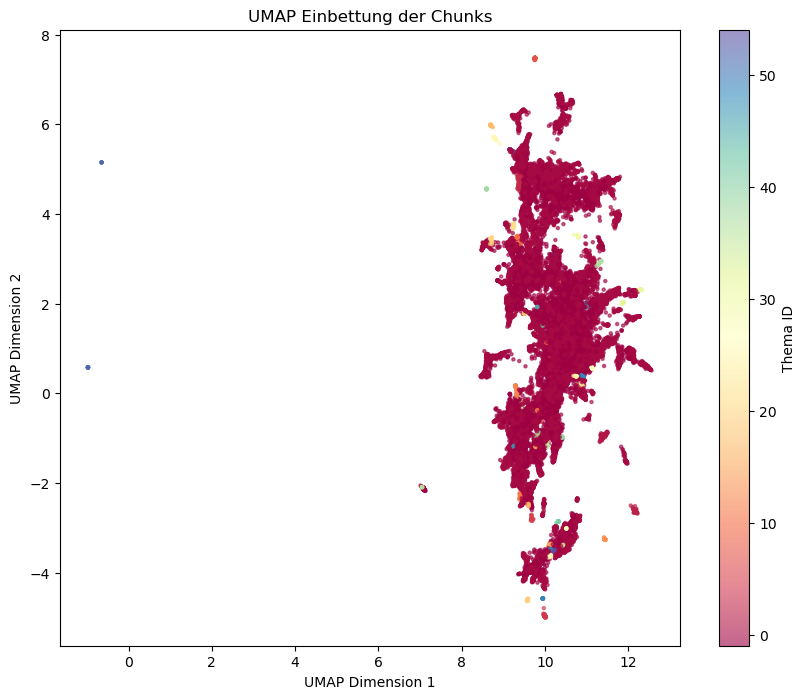

In [39]:
import matplotlib.pyplot as plt

# 1. Die bereits berechneten 2D-Koordinaten direkt aus BERTopic ziehen
umap_embeddings = topic_model.umap_model.embedding_

# 2. Scatterplot erstellen (Variablen an deinen Code angepasst)
plt.figure(figsize=(10, 8))
plt.scatter(
    umap_embeddings[:, 0], 
    umap_embeddings[:, 1], 
    c=topics,          # Deine Variable aus fit_transform
    cmap='Spectral', 
    s=5, 
    alpha=0.6
)
plt.colorbar(label='Thema ID')
plt.title('UMAP Einbettung der Chunks')
plt.xlabel('UMAP Dimension 1')
plt.ylabel('UMAP Dimension 2')

plt.savefig("umap__800_v1.jpg", format="jpg", dpi=150, bbox_inches='tight')

plt.show()

In [40]:
topic_info = topic_model.get_topic_info()
topic_info.head(25)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,9978,-1_co2_israel_china_migration,"[co2, israel, china, migration, russland, indu...","[. Das ist genau richtig, aus verschiedenen Gr..."
1,0,32970,0_bundeswehr_soldaten_russland_israel,"[bundeswehr, soldaten, russland, israel, impfp...",[. Ich will Sie deshalb sehr ernsthaft fragen:...
2,1,185,1_sport_athleten_spitzensport_special,"[sport, athleten, spitzensport, special, speci...",[Sehr verehrte Sehr verehrte Kolleginnen! Es w...
3,2,181,2_cannabis_konsum_schwarzmarkt_legalisierung,"[cannabis, konsum, schwarzmarkt, legalisierung...",[vielen Dank für diese Frage. Zunächst einmal:...
4,3,189,3_syrien_assad_syrer_sturz,"[syrien, assad, syrer, sturz, syrischen, syrer...",[Ich möchte meine Frage gerne an Bundesministe...
5,4,97,4_organspende_widerspruchslösung_widerspruchsr...,"[organspende, widerspruchslösung, widerspruchs...",[. Seit 2020 sollen Ärzte und Bürgerämter aufk...
6,5,86,5_sprind_sprunginnovationen_freiheitsgesetz_sp...,"[sprind, sprunginnovationen, freiheitsgesetz, ...","[. Und hinter bahnbrechenden Innovationen, da ..."
7,6,106,6_verpackungsverordnung_verpackungen_müll_plas...,"[verpackungsverordnung, verpackungen, müll, pl...","[. Ich fand das wirklich sehr beeindruckend, z..."
8,7,76,7_nordkorea_korea_südkorea_koreanischen,"[nordkorea, korea, südkorea, koreanischen, hal...",[140 Jahre diplomatische Beziehungen zu Korea ...
9,8,98,8_telegram_meinungsfreiheit_plattformen_hass,"[telegram, meinungsfreiheit, plattformen, hass...",[. Aber auch inhaltlich ist der Antrag mau. Vi...


In [41]:
#   TEST 2

umap_model = UMAP(
    n_neighbors= 15,  # 8
    n_components= 4,    # 5
    min_dist=0.0,
    metric="cosine",
    random_state=42
)

hdbscan_model = HDBSCAN(
    min_cluster_size=12,
    min_samples=4,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True
)

vectorizer_model = CountVectorizer(
    stop_words=stoppwörter,
    ngram_range=(1, 2),
    max_df=0.2
)

# c-TF-IDF definieren  ==> 'reduce_frequent_words' aktiviert die automatische Herabstufung von parteiübergreifenden Floskeln
# bm25_weighting ==> Kompensation der Dokumentenlänge
ctfidf_model = ClassTfidfTransformer(reduce_frequent_words=True, bm25_weighting=True)   # ggf. Parameter einbinden 'seed_multiplier=2'

#Dem Modell mitteilen, dass es standardmäßig die Clustering-Task nutzen soll
# Dadurch wird bei jedem internen Aufruf von BERTopic automatisch der richtige LoRA-Adapter gewählt.
embedding_model.encode_kwargs = {"task": "separation"}

# Guided BERTopic initialisieren
topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    seed_topic_list=seed_topic_list,   # die 13 Kategorien
    calculate_probabilities=False,  # True auch möglich
    nr_topics='auto',
    verbose=True
)

# Modell trainieren
topics, probabilities = topic_model.fit_transform(alle_chunks)

2026-09-04 18:27:21,647 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/1432 [00:00<?, ?it/s]

2026-09-04 18:28:53,490 - BERTopic - Embedding - Completed ✓
2026-09-04 18:28:53,492 - BERTopic - Guided - Find embeddings highly related to seeded topics.


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

2026-09-04 18:28:53,793 - BERTopic - Guided - Completed ✓
2026-09-04 18:28:53,794 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-09-04 18:29:37,600 - BERTopic - Dimensionality - Completed ✓
2026-09-04 18:29:37,604 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-09-04 18:29:39,734 - BERTopic - Cluster - Completed ✓
2026-09-04 18:29:39,735 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-09-04 18:29:52,919 - BERTopic - Representation - Completed ✓
2026-09-04 18:29:52,938 - BERTopic - Topic reduction - Reducing number of topics
2026-09-04 18:29:53,640 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-09-04 18:30:06,944 - BERTopic - Representation - Completed ✓
2026-09-04 18:30:06,963 - BERTopic - Topic reduction - Reduced number of topics from 486 to 312


In [42]:
# ============================================================
# 1. Ursprüngliche BERTopic-Zuordnung & Wahrscheinlichkeiten speichern
# ============================================================

topics_original = topic_model.topics_
probabilities_original = topic_model.probabilities_ 

print("Anzahl Chunks:", len(alle_chunks))
print("Outlier vorher:", sum(t == -1 for t in topics_original))

# ============================================================
# 2. Outlier reduzieren, Threshold 70%
# ============================================================

topics_reduced_outliers = topic_model.reduce_outliers(
    alle_chunks,
    topics_original,
    strategy="embeddings",
    threshold=0.70
)

print(
    "Outlier nach reduce_outliers:",
    sum(t == -1 for t in topics_reduced_outliers)
)

# ============================================================
# 3. Aktualisierte Topic-Zuordnung in BERTopic übernehmen
# ============================================================

topic_model.update_topics(
    alle_chunks,
    topics=topics_reduced_outliers,
    vectorizer_model=vectorizer_model
)

topics_x = topic_model.topics_

# ============================================================
# 4. Informationen über die Cluster
# ============================================================

topic_info_x = topic_model.get_topic_info()

print(
    topic_info_x[
        ["Topic", "Count", "Name"]
    ].sort_values("Count", ascending=False)
)

Anzahl Chunks: 45802
Outlier vorher: 15972


2026-09-04 18:31:16,337 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.


Outlier nach reduce_outliers: 3082
     Topic  Count                                               Name
1        0   4901   0_bürgergeld_wirtschaftspolitik_erneuerbaren_eeg
0       -1   3082       -1_bürgergeld_friedrich_nachfragen_identität
2        1   1838                1_israel_hamas_antisemitismus_juden
3        2   1463                  2_putin_russischen_russische_nato
6        5   1239  5_migrationspolitik_geflüchtete_abschiebungen_...
..     ...    ...                                                ...
289    288     16          288_höfeordnung_erben_grundsteuerwert_hof
278    277     16  277_aserbaidschan_klimakonferenz_politischen g...
290    289     15  289_digitale gewalt_männer sexualisierter_angr...
304    303     13  303_bankenunion_einlagensicherung_risikoreduzi...
308    307     13  307_who_millionen gestrichen_pandemievertrag w...

[312 rows x 3 columns]


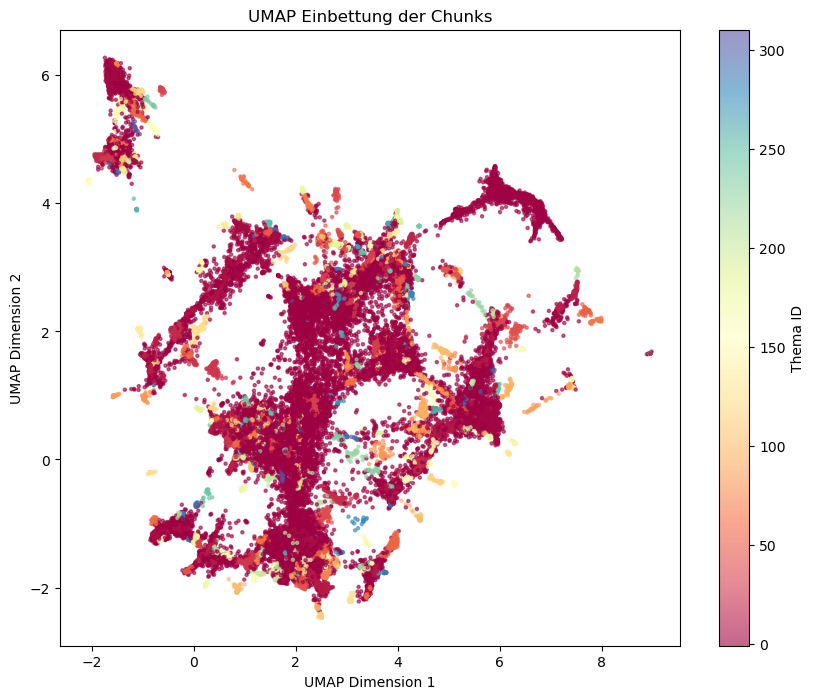

In [43]:
import matplotlib.pyplot as plt

# 1. Die bereits berechneten 2D-Koordinaten direkt aus BERTopic ziehen
umap_embeddings = topic_model.umap_model.embedding_

# 2. Scatterplot erstellen (Variablen an deinen Code angepasst)
plt.figure(figsize=(10, 8))
plt.scatter(
    umap_embeddings[:, 0], 
    umap_embeddings[:, 1], 
    c=topics,          # Deine Variable aus fit_transform
    cmap='Spectral', 
    s=5, 
    alpha=0.6
)
plt.colorbar(label='Thema ID')
plt.title('UMAP Einbettung der Chunks')
plt.xlabel('UMAP Dimension 1')
plt.ylabel('UMAP Dimension 2')

plt.savefig("umap__800_v2.jpg", format="jpg", dpi=150, bbox_inches='tight')

plt.show()

In [44]:
topic_info = topic_model.get_topic_info()
topic_info.head(25)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,3082,-1_bürgergeld_friedrich_nachfragen_identität,"[bürgergeld, friedrich, nachfragen, identität,...",[. Das passiert mit der CO2-Abgabe. Das ist da...
1,0,4901,0_bürgergeld_wirtschaftspolitik_erneuerbaren_eeg,"[bürgergeld, wirtschaftspolitik, erneuerbaren,...","[. Und nein, die Schuldenbremse ist kein Selbs..."
2,1,1838,1_israel_hamas_antisemitismus_juden,"[israel, hamas, antisemitismus, juden, israels...","[. Die Mörder der Hamas wüteten bestialisch, w..."
3,2,1463,2_putin_russischen_russische_nato,"[putin, russischen, russische, nato, putins, r...","[. Das Modell einer Ukraine, die demokratisch,..."
4,3,831,3_impfpflicht_impfung_impfen_allgemeine impfpf...,"[impfpflicht, impfung, impfen, allgemeine impf...",[. Auch für die müssen wir sagen: allgemeine I...
5,4,760,4_gewalt frauen_schwangerschaftsabbrüche_schwa...,"[gewalt frauen, schwangerschaftsabbrüche, schw...",[. In 85 von 400 Landkreisen werden nicht die ...
6,5,1239,5_migrationspolitik_geflüchtete_abschiebungen_...,"[migrationspolitik, geflüchtete, abschiebungen...",[. Das genaue Gegenteil ist der Fall: Unser La...
7,6,818,6_klimawandel_klimaanpassung_klimakrise_klimap...,"[klimawandel, klimaanpassung, klimakrise, klim...","[Sie behaupten, Sie würden den menschengemacht..."
8,7,785,7_mietpreisbremse_wohnungen_wohnraum_mieten,"[mietpreisbremse, wohnungen, wohnraum, mieten,...","[Die Verlängerung der Mietpreisbremse kommt, u..."
9,8,607,8_kindergrundsicherung_elterngeld_kita_kitas,"[kindergrundsicherung, elterngeld, kita, kitas...",[. Diese Bundesregierung stellt für den Ausbau...


In [45]:
#   TEST 3

umap_model = UMAP(
    n_neighbors= 30,  # 15, 8
    n_components= 2,    # 4, 5
    min_dist=0.0,
    metric="cosine",
    random_state=42
)

hdbscan_model = HDBSCAN(
    min_cluster_size=15,   # 12
    min_samples=4,           # 4
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True
)

vectorizer_model = CountVectorizer(
    stop_words=stoppwörter,
    ngram_range=(1, 2),
    max_df=0.2
)

vectorizer_model = CountVectorizer(
    stop_words=stoppwörter,
    ngram_range=(1, 2),
    max_df=0.2
)

# c-TF-IDF definieren  ==> 'reduce_frequent_words' aktiviert die automatische Herabstufung von parteiübergreifenden Floskeln
# bm25_weighting ==> Kompensation der Dokumentenlänge
ctfidf_model = ClassTfidfTransformer(reduce_frequent_words=True, bm25_weighting=True)   # ggf. Parameter einbinden 'seed_multiplier=2'

#Dem Modell mitteilen, dass es standardmäßig die Clustering-Task nutzen soll
# Dadurch wird bei jedem internen Aufruf von BERTopic automatisch der richtige LoRA-Adapter gewählt.
embedding_model.encode_kwargs = {"task": "separation"}

# Guided BERTopic initialisieren
topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    seed_topic_list=seed_topic_list,   # die 13 Kategorien
    calculate_probabilities=False,  # True auch möglich
    nr_topics='auto',
    verbose=True
)

# Modell trainieren
topics, probabilities = topic_model.fit_transform(alle_chunks)

2026-09-04 18:31:47,745 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/1432 [00:00<?, ?it/s]

2026-09-04 18:33:18,958 - BERTopic - Embedding - Completed ✓
2026-09-04 18:33:18,960 - BERTopic - Guided - Find embeddings highly related to seeded topics.


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

2026-09-04 18:33:19,268 - BERTopic - Guided - Completed ✓
2026-09-04 18:33:19,269 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-09-04 18:34:21,707 - BERTopic - Dimensionality - Completed ✓
2026-09-04 18:34:21,709 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-09-04 18:34:22,606 - BERTopic - Cluster - Completed ✓
2026-09-04 18:34:22,607 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-09-04 18:34:37,864 - BERTopic - Representation - Completed ✓
2026-09-04 18:34:37,884 - BERTopic - Topic reduction - Reducing number of topics
2026-09-04 18:34:38,483 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-09-04 18:34:53,710 - BERTopic - Representation - Completed ✓
2026-09-04 18:34:53,733 - BERTopic - Topic reduction - Reduced number of topics from 443 to 230


In [46]:
# ============================================================
# 1. Ursprüngliche BERTopic-Zuordnung & Wahrscheinlichkeiten speichern
# ============================================================

topics_original = topic_model.topics_
probabilities_original = topic_model.probabilities_ 

print("Anzahl Chunks:", len(alle_chunks))
print("Outlier vorher:", sum(t == -1 for t in topics_original))

# ============================================================
# 2. Outlier reduzieren, Threshold 70%
# ============================================================

topics_reduced_outliers = topic_model.reduce_outliers(
    alle_chunks,
    topics_original,
    strategy="embeddings",
    threshold=0.70
)

print(
    "Outlier nach reduce_outliers:",
    sum(t == -1 for t in topics_reduced_outliers)
)

# ============================================================
# 3. Aktualisierte Topic-Zuordnung in BERTopic übernehmen
# ============================================================

topic_model.update_topics(
    alle_chunks,
    topics=topics_reduced_outliers,
    vectorizer_model=vectorizer_model
)

topics_x = topic_model.topics_

# ============================================================
# 4. Informationen über die Cluster
# ============================================================

topic_info_x = topic_model.get_topic_info()

print(
    topic_info_x[
        ["Topic", "Count", "Name"]
    ].sort_values("Count", ascending=False)
)

Anzahl Chunks: 45802
Outlier vorher: 13479


2026-09-04 18:35:24,140 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.


Outlier nach reduce_outliers: 3142
     Topic  Count                                               Name
1        0   8015              0_erneuerbaren_strom_energiewende_gas
0       -1   3142           -1_meinungsfreiheit_türkei_schüler_covid
2        1   2675  1_nato_diplomatie_soldatinnen soldaten_soldati...
4        3   1615  3_kindergrundsicherung_gewalt frauen_kita_elte...
6        5   1494  5_migrationspolitik_einbürgerung_staatsbürgers...
..     ...    ...                                                ...
204    203     22  203_prostitution_menschenhandel_sexkaufverbot_...
206    205     21   205_reparatur_recht reparatur_updates_langlebige
229    228     21  228_öffentlichen dienst_beamten_beamtinnen bea...
218    217     20  217_reallabore_regulatorisches_regulatorisches...
211    210     20  210_einsamkeit_thema einsamkeit_einsamkeitsstr...

[230 rows x 3 columns]


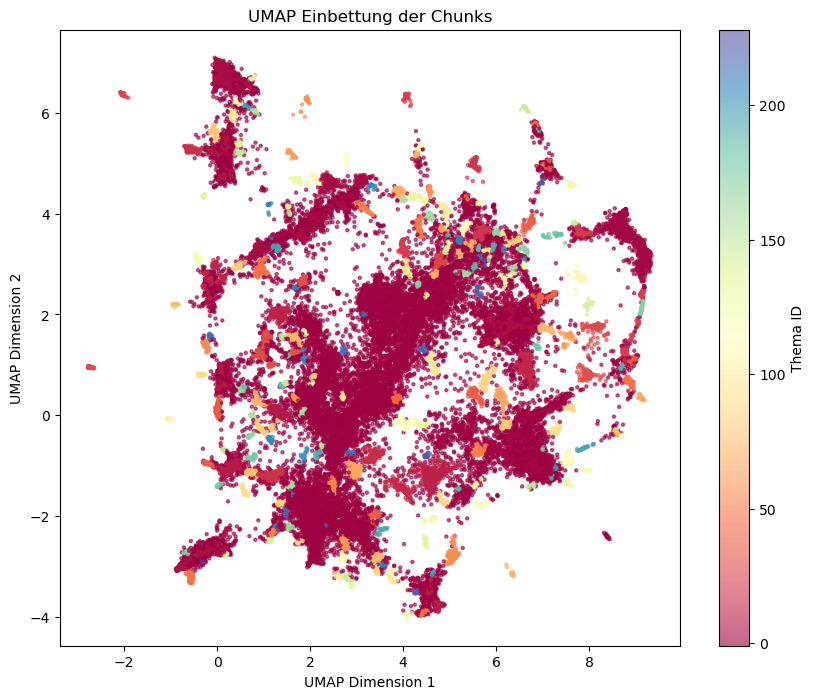

In [47]:
import matplotlib.pyplot as plt

# 1. Die bereits berechneten 2D-Koordinaten direkt aus BERTopic ziehen
umap_embeddings = topic_model.umap_model.embedding_

# 2. Scatterplot erstellen (Variablen an deinen Code angepasst)
plt.figure(figsize=(10, 8))
plt.scatter(
    umap_embeddings[:, 0], 
    umap_embeddings[:, 1], 
    c=topics,          # Deine Variable aus fit_transform
    cmap='Spectral', 
    s=5, 
    alpha=0.6
)
plt.colorbar(label='Thema ID')
plt.title('UMAP Einbettung der Chunks')
plt.xlabel('UMAP Dimension 1')
plt.ylabel('UMAP Dimension 2')

plt.savefig("umap__800_v3.jpg", format="jpg", dpi=150, bbox_inches='tight')

plt.show()

In [48]:
topic_info = topic_model.get_topic_info()
topic_info.head(25)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,3142,-1_meinungsfreiheit_türkei_schüler_covid,"[meinungsfreiheit, türkei, schüler, covid, tru...","[Sie rühmen sich, die Meinungsfreiheit hochzuh..."
1,0,8015,0_erneuerbaren_strom_energiewende_gas,"[erneuerbaren, strom, energiewende, gas, erneu...",[. Der gleichzeitige Ausstieg aus Kohle und Ke...
2,1,2675,1_nato_diplomatie_soldatinnen soldaten_soldati...,"[nato, diplomatie, soldatinnen soldaten, solda...",[. Denn die Lage ist dramatisch: Mit unvermind...
3,2,1480,2_israel_hamas_antisemitismus_juden,"[israel, hamas, antisemitismus, juden, israels...",[. An der Spitze steht die Hamas. Aus ihren Ab...
4,3,1615,3_kindergrundsicherung_gewalt frauen_kita_elte...,"[kindergrundsicherung, gewalt frauen, kita, el...",[Der Antrag der Linken macht durchaus auf ein ...
5,4,1023,4_impfpflicht_impfung_impfen_allgemeine,"[impfpflicht, impfung, impfen, allgemeine, all...",[Die Gegner der Impfpflicht waren deutlich mot...
6,5,1494,5_migrationspolitik_einbürgerung_staatsbürgers...,"[migrationspolitik, einbürgerung, staatsbürger...",[Vor der Bundestagswahl 2025 versprachen CDU u...
7,6,1009,6_mietpreisbremse_wohnraum_mieten_wohnungsbau,"[mietpreisbremse, wohnraum, mieten, wohnungsba...",[Ende 2025 laufen die Mietpreisbremsen aus. Di...
8,7,880,7_krankenhäuser_patienten_pflegeversicherung_g...,"[krankenhäuser, patienten, pflegeversicherung,...",[Als Freie Demokraten setzen wir uns dafür ein...
9,8,721,8_one_digitalpolitik_normenkontrollrat_bürokra...,"[one, digitalpolitik, normenkontrollrat, bürok...","[Mal hü, mal hott nach diesem Prinzip agiert d..."


In [49]:
#   TEST 4

umap_model = UMAP(
    n_neighbors= 40,  # 30, 15, 8
    n_components= 2,    # 4, 5
    min_dist=0.0,
    metric="cosine",
    random_state=42
)

hdbscan_model = HDBSCAN(
    min_cluster_size=15,   # 12
    min_samples=4,           # 4
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True
)


vectorizer_model = CountVectorizer(
    stop_words=stoppwörter,
    ngram_range=(1, 2),
    max_df=0.2
)

# c-TF-IDF definieren  ==> 'reduce_frequent_words' aktiviert die automatische Herabstufung von parteiübergreifenden Floskeln
# bm25_weighting ==> Kompensation der Dokumentenlänge
ctfidf_model = ClassTfidfTransformer(reduce_frequent_words=True, bm25_weighting=True)   # ggf. Parameter einbinden 'seed_multiplier=2'

#Dem Modell mitteilen, dass es standardmäßig die Clustering-Task nutzen soll
# Dadurch wird bei jedem internen Aufruf von BERTopic automatisch der richtige LoRA-Adapter gewählt.
embedding_model.encode_kwargs = {"task": "separation"}

# Guided BERTopic initialisieren
topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    seed_topic_list=seed_topic_list,   # die 13 Kategorien
    calculate_probabilities=False,  # True auch möglich
    nr_topics='auto',
    verbose=True
)

# Modell trainieren
topics, probabilities = topic_model.fit_transform(alle_chunks)

2026-09-04 18:36:04,551 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/1432 [00:00<?, ?it/s]

2026-09-04 18:37:33,727 - BERTopic - Embedding - Completed ✓
2026-09-04 18:37:33,728 - BERTopic - Guided - Find embeddings highly related to seeded topics.


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

2026-09-04 18:37:34,032 - BERTopic - Guided - Completed ✓
2026-09-04 18:37:34,032 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-09-04 18:38:50,692 - BERTopic - Dimensionality - Completed ✓
2026-09-04 18:38:50,696 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-09-04 18:38:51,566 - BERTopic - Cluster - Completed ✓
2026-09-04 18:38:51,567 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-09-04 18:39:04,875 - BERTopic - Representation - Completed ✓
2026-09-04 18:39:04,888 - BERTopic - Topic reduction - Reducing number of topics
2026-09-04 18:39:05,452 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-09-04 18:39:18,950 - BERTopic - Representation - Completed ✓
2026-09-04 18:39:18,970 - BERTopic - Topic reduction - Reduced number of topics from 429 to 204


In [50]:
# ============================================================
# 1. Ursprüngliche BERTopic-Zuordnung & Wahrscheinlichkeiten speichern
# ============================================================

topics_original = topic_model.topics_
probabilities_original = topic_model.probabilities_ 

print("Anzahl Chunks:", len(alle_chunks))
print("Outlier vorher:", sum(t == -1 for t in topics_original))

# ============================================================
# 2. Outlier reduzieren, Threshold 70%
# ============================================================

topics_reduced_outliers = topic_model.reduce_outliers(
    alle_chunks,
    topics_original,
    strategy="embeddings",
    threshold=0.70
)

print(
    "Outlier nach reduce_outliers:",
    sum(t == -1 for t in topics_reduced_outliers)
)

# ============================================================
# 3. Aktualisierte Topic-Zuordnung in BERTopic übernehmen
# ============================================================

topic_model.update_topics(
    alle_chunks,
    topics=topics_reduced_outliers,
    vectorizer_model=vectorizer_model
)

topics_x = topic_model.topics_

# ============================================================
# 4. Informationen über die Cluster
# ============================================================

topic_info_x = topic_model.get_topic_info()

print(
    topic_info_x[
        ["Topic", "Count", "Name"]
    ].sort_values("Count", ascending=False)
)

Anzahl Chunks: 45802
Outlier vorher: 13122


2026-09-04 18:40:16,673 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.


Outlier nach reduce_outliers: 3248
     Topic  Count                                               Name
1        0   7822  0_erneuerbaren_wasserstoff_erneuerbaren energi...
0       -1   3248        -1_geschäftsordnung_covid_brandner_klöckner
2        1   1899  1_nato_diplomatie_ukrainischen_unterstützung u...
7        6   1589  6_migrationspolitik_einbürgerung_asyl_grenzkon...
3        2   1479                2_israel_hamas_antisemitismus_juden
..     ...    ...                                                ...
202    201     25  201_islamismusprävention_taskforce_deradikalis...
196    195     24  195_prostitution_sexkaufverbot_prostituierte_v...
188    187     22  187_who_tuberkulose malaria_fonds bekämpfung_t...
189    188     22  188_reallabore_regulatorisches_regulatorisches...
194    193     18  193_einsamkeit_thema einsamkeit_einsamkeitsstr...

[204 rows x 3 columns]


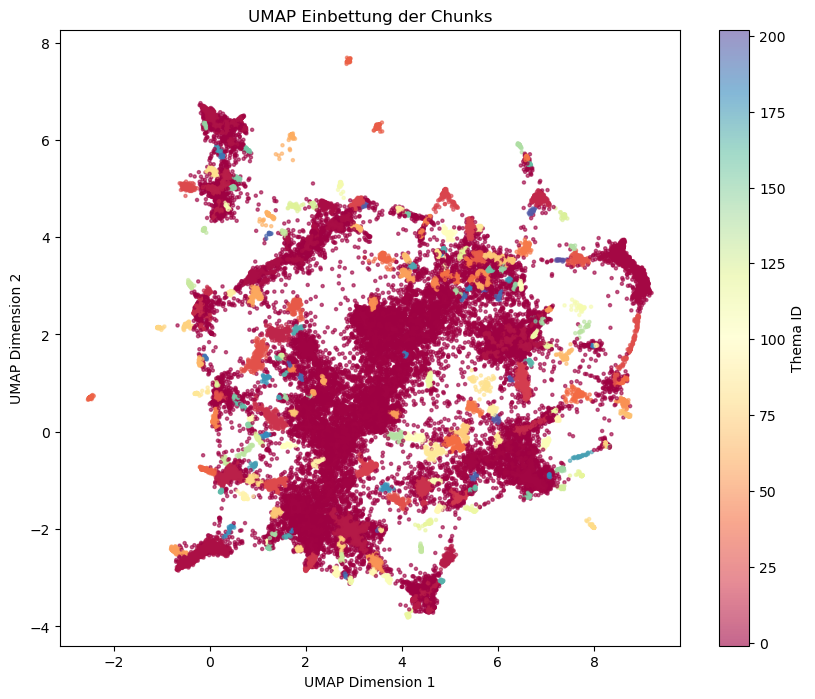

In [51]:
import matplotlib.pyplot as plt

# 1. Die bereits berechneten 2D-Koordinaten direkt aus BERTopic ziehen
umap_embeddings = topic_model.umap_model.embedding_

# 2. Scatterplot erstellen (Variablen an deinen Code angepasst)
plt.figure(figsize=(10, 8))
plt.scatter(
    umap_embeddings[:, 0], 
    umap_embeddings[:, 1], 
    c=topics,          # Deine Variable aus fit_transform
    cmap='Spectral', 
    s=5, 
    alpha=0.6
)
plt.colorbar(label='Thema ID')
plt.title('UMAP Einbettung der Chunks')
plt.xlabel('UMAP Dimension 1')
plt.ylabel('UMAP Dimension 2')

plt.savefig("umap__800_v4.jpg", format="jpg", dpi=150, bbox_inches='tight')

plt.show()

In [52]:
topic_info = topic_model.get_topic_info()
topic_info.head(25)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,3248,-1_geschäftsordnung_covid_brandner_klöckner,"[geschäftsordnung, covid, brandner, klöckner, ...",[. Sie kürzen bei der Entwicklungszusammenarbe...
1,0,7822,0_erneuerbaren_wasserstoff_erneuerbaren energi...,"[erneuerbaren, wasserstoff, erneuerbaren energ...",[. Das werden wir bald angehen. Die massiven P...
2,1,1899,1_nato_diplomatie_ukrainischen_unterstützung u...,"[nato, diplomatie, ukrainischen, unterstützung...",[. Die 25-Millionen-Euro-Vorlagen werden erhal...
3,2,1479,2_israel_hamas_antisemitismus_juden,"[israel, hamas, antisemitismus, juden, israels...","[. Auch diese Kinder haben Namen, sie haben Ge..."
4,3,1457,3_kindergrundsicherung_kita_elterngeld_schüler,"[kindergrundsicherung, kita, elterngeld, schül...",[. Das ist echt ein billiger Versuch. Glauben ...
5,4,1265,4_wohnungen_mietpreisbremse_wohnraum_wohnungsbau,"[wohnungen, mietpreisbremse, wohnraum, wohnung...",[. Klar ist auch: Mieterschutz allein reicht n...
6,5,1162,5_impfpflicht_impfung_impfen_omikron,"[impfpflicht, impfung, impfen, omikron, allgem...",[. Wir müssen uns vielmehr darüber verständige...
7,6,1589,6_migrationspolitik_einbürgerung_asyl_grenzkon...,"[migrationspolitik, einbürgerung, asyl, grenzk...",[. Das ist nichts anderes als ein Senken der Q...
8,7,1035,7_klimapolitik_klimaanpassung_cop_klimawandels,"[klimapolitik, klimaanpassung, cop, klimawande...",[. Ihre Forderungen nehme ich persönlich für u...
9,8,1013,8_landwirte_bauern_lebensmittel_ernährung,"[landwirte, bauern, lebensmittel, ernährung, t...",[. Jede und jeder sollte Zugang zu hochwertige...
